# Proyecto Final ISID223 — Sistema de Gestión para Gimnasio "FitZone"

Este notebook implementa el sistema principal (Core Business) de ventas de un gimnasio, junto con
tres módulos de apoyo (ERP, SCM y CRM) que se conectan automáticamente entre sí, un análisis RFM
de clientes y un dashboard gerencial. Todo el código está pensado para ejecutarse en Google Colab.

**Importante:** antes de correr la celda de carga de datos, sube el archivo `gym_churn_us.csv`
a los archivos de tu sesión de Colab (ícono de carpeta a la izquierda -> Subir).

In [15]:
# Librerías que vamos a usar en todo el notebook
import pandas as pd
import matplotlib.pyplot as plt
import random
from datetime import datetime, timedelta

random.seed(7)  # para que la simulación salga igual cada vez que se ejecuta

## 1. Núcleo del sistema (Core Business)

Aquí creamos las tres clases básicas del negocio: `Cliente`, `Producto` y `Venta`.
Son clases simples, solo guardan datos (atributos) de cada cliente, producto o venta realizada.
Más abajo la clase `Gimnasio` las usa para registrar las ventas del día a día.

In [16]:
class Cliente:
    def __init__(self, id_cliente, nombre, edad, fecha_registro):
        self.id_cliente = id_cliente
        self.nombre = nombre
        self.edad = edad
        self.fecha_registro = fecha_registro
        self.ultima_compra = fecha_registro  # se va a actualizar cada vez que compre algo

    def __str__(self):
        return f"{self.nombre} (id={self.id_cliente}, edad={self.edad})"

In [17]:
class Producto:
    def __init__(self, id_producto, nombre, precio, stock):
        self.id_producto = id_producto
        self.nombre = nombre
        self.precio = precio
        self.stock = stock

    def __str__(self):
        return f"{self.nombre} (stock={self.stock}, precio=${self.precio})"

In [18]:
class Venta:
    def __init__(self, id_venta, cliente, producto, cantidad, fecha):
        self.id_venta = id_venta
        self.cliente = cliente
        self.producto = producto
        self.cantidad = cantidad
        self.fecha = fecha
        self.total = producto.precio * cantidad

## 2. Módulo ERP (Mini-Financiero)

Este módulo simula la "caja chica" del gimnasio. Cada vez que el sistema principal registra
una venta, el módulo ERP recibe el monto y lo suma automáticamente a la caja, además de
guardar el movimiento en una lista de historial contable.

In [19]:
class ModuloERP:
    def __init__(self):
        self.caja_chica = 0
        self.movimientos = []

    def registrar_ingreso(self, monto, descripcion, fecha):
        self.caja_chica += monto
        self.movimientos.append({"fecha": fecha, "descripcion": descripcion, "monto": monto})
        print(f"[ERP] Ingreso de ${monto:.2f} registrado. Caja chica actual: ${self.caja_chica:.2f}")

## 3. Módulo SCM (Inventario y Proveedores)

Este módulo revisa el stock del producto vendido. Si el stock queda igual o por debajo del
mínimo permitido, genera automáticamente una "Orden de Compra" hacia un proveedor simulado, y
esa orden repone el stock al instante (simulando que el proveedor entrega el pedido), sin que
un humano tenga que pedirlo ni reabastecer el producto manualmente.

In [20]:
class ModuloSCM:
    def __init__(self, stock_minimo=5, cantidad_pedido=20):
        self.stock_minimo = stock_minimo
        self.cantidad_pedido = cantidad_pedido
        self.ordenes_compra = []

    def verificar_stock(self, producto, fecha):
        if producto.stock <= self.stock_minimo:
            orden = {
                "fecha": fecha,
                "producto": producto.nombre,
                "cantidad_pedida": self.cantidad_pedido,
                "proveedor": "Proveedor Simulado S.A."
            }
            self.ordenes_compra.append(orden)

            # Simulamos que el proveedor entrega el pedido de inmediato,
            # así el producto nunca se queda atascado en 0 unidades.
            producto.stock += self.cantidad_pedido

            print(f"[SCM] Stock bajo de '{producto.nombre}'. Se genera orden de compra "
                  f"automática al proveedor y se repone stock a {producto.stock} unidades.")

## 4. Módulo CRM (Riesgo de Deserción)

Este módulo recorre a todos los clientes y calcula cuántos días han pasado desde su última
compra. Si un cliente supera el umbral de inactividad definido, se marca en riesgo y se
guarda una alerta que luego se muestra en el panel gerencial.

In [21]:
class ModuloCRM:
    def __init__(self, tiempo_dias=20):
        self.tiempo_dias = tiempo_dias
        self.alertas = []

    def revisar_clientes(self, clientes, fecha_actual):
        self.alertas = []  # limpiamos alertas anteriores antes de revisar de nuevo
        for cliente in clientes:
            dias_inactivo = (fecha_actual - cliente.ultima_compra).days
            if dias_inactivo >= self.tiempo_dias:
                self.alertas.append(f"Cliente en Riesgo de Deserción: {cliente.nombre} "
                                     f"({dias_inactivo} días sin comprar)")
        return self.alertas

## 5. Sistema principal: clase `Gimnasio`

La clase `Gimnasio` es el sistema central. Guarda las listas de clientes, productos y ventas,
y en su método `registrar_venta` es donde ocurre la integración: además de guardar la venta,
llama automáticamente al módulo ERP y al módulo SCM, sin intervención manual.

In [22]:
class Gimnasio:
    def __init__(self, erp, scm):
        self.clientes = []
        self.productos = []
        self.ventas = []
        self.erp = erp   # conexión con el módulo ERP
        self.scm = scm   # conexión con el módulo SCM

    def registrar_venta(self, cliente, producto, cantidad, fecha):
        if producto.stock < cantidad:
            print(f"No hay stock suficiente de '{producto.nombre}'.")
            return None

        id_venta = len(self.ventas) + 1
        venta = Venta(id_venta, cliente, producto, cantidad, fecha)

        # Actualizamos el estado del negocio
        producto.stock -= cantidad
        if fecha > cliente.ultima_compra:  # solo si es más reciente que la que ya tenía
            cliente.ultima_compra = fecha
        self.ventas.append(venta)

        print(f"Venta registrada: {cliente.nombre} compró {cantidad} x {producto.nombre} "
              f"= ${venta.total:.2f}")

        # --- Aquí ocurre la integración automática con los otros sistemas ---
        self.erp.registrar_ingreso(venta.total, f"Venta #{id_venta}", fecha)
        self.scm.verificar_stock(producto, fecha)

        return venta

## 6. Carga de clientes reales del gimnasio

Usamos el dataset real `gym_churn_us.csv` (histórico de ~4000 clientes de un gimnasio) para
crear a TODOS los clientes iniciales del sistema, tomando su edad real. El dataset también
trae una columna real `Churn` (1 = ya se dio de baja, 0 = sigue activo), que usamos para que
la última compra de cada cliente sea coherente con su comportamiento real: los que en la vida
real ya se fueron (`Churn=1`) arrancan con una compra antigua, y los que siguen activos
(`Churn=0`) arrancan con una compra reciente.

In [23]:

df_clientes_reales = pd.read_csv("gym_churn_us.csv")

hoy = datetime(2026, 7, 19)  # "fecha actual" que usaremos en toda la simulación
clientes = []

# Creamos un objeto Cliente por cada fila real del dataset (Cliente_1 ... Cliente_N)
for i in range(len(df_clientes_reales)):
    edad = int(df_clientes_reales.loc[i, "Age"])
    churn_real = int(df_clientes_reales.loc[i, "Churn"])  # 1 = ya se fue, 0 = sigue activo

    if churn_real == 1:
        dias_atras = random.randint(35, 90)   # ya no compra hace tiempo
    else:
        dias_atras = random.randint(1, 15)    # sigue comprando recientemente

    fecha_registro = hoy - timedelta(days=dias_atras)
    cliente = Cliente(id_cliente=i + 1, nombre=f"Cliente_{i+1}", edad=edad, fecha_registro=fecha_registro)
    cliente.churn_real = churn_real  # guardamos el dato real para comparar más adelante
    clientes.append(cliente)

print(f"Se crearon {len(clientes)} clientes a partir del dataset real.")

Se crearon 4000 clientes a partir del dataset real.


In [24]:
# Productos/servicios del gimnasio. Dejamos algunos con stock bajo a propósito
# para poder demostrar en vivo cómo se dispara la orden de compra del módulo SCM.
productos = [
    Producto(1, "Membresía Mensual", 30.0, 100),
    Producto(2, "Proteína en polvo", 25.0, 8),
    Producto(3, "Botella deportiva", 8.0, 15),
    Producto(4, "Clase personalizada", 15.0, 50),
    Producto(5, "Suplemento vitamínico", 12.0, 4),
]

for p in productos:
    print(p)

Membresía Mensual (stock=100, precio=$30.0)
Proteína en polvo (stock=8, precio=$25.0)
Botella deportiva (stock=15, precio=$8.0)
Clase personalizada (stock=50, precio=$15.0)
Suplemento vitamínico (stock=4, precio=$12.0)


In [25]:
erp = ModuloERP()
scm = ModuloSCM(stock_minimo=5)
crm = ModuloCRM(tiempo_dias=20)

gimnasio = Gimnasio(erp, scm)
gimnasio.clientes = clientes
gimnasio.productos = productos

## 7. Simulación de historial de ventas (últimos 60 días)

Para poder calcular el RFM y armar el dashboard necesitamos un historial de ventas. Por eso
simulamos ventas aleatorias entre los clientes y productos durante los últimos 60 días,
usando siempre el mismo método `registrar_venta` (así se sigue disparando ERP y SCM).

In [26]:
# Solo simulamos ventas entre los clientes que en la vida real seguían activos (Churn=0).
# A los que ya se dieron de baja (Churn=1) no les generamos ninguna venta nueva, para que
# el sistema los detecte como "en riesgo" de forma consistente con el dato real.
clientes_activos = [c for c in clientes if c.churn_real == 0]

for dia in range(60, 0, -1): #recorre los ultimos 60 días
    fecha_venta = hoy - timedelta(days=dia) #calcula la fecha de ese día
    num_ventas_del_dia = random.randint(1, 5) #genera una cantidad de venta random
    for _ in range(num_ventas_del_dia): #se repite el proceso por cada venta
        cliente_random = random.choice(clientes_activos) #elige random cliente
        producto_random = random.choice(productos) # elige random producto
        cantidad = random.randint(1, 2)  #una cantidad random
        gimnasio.registrar_venta(cliente_random, producto_random, cantidad, fecha_venta) #registra cada dato

print("\n--- Resumen del historial simulado ---")
print(f"Total de ventas históricas: {len(gimnasio.ventas)}")
print(f"Caja chica acumulada: ${erp.caja_chica:.2f}")
print(f"Órdenes de compra generadas por SCM: {len(scm.ordenes_compra)}")

Venta registrada: Cliente_3961 compró 1 x Suplemento vitamínico = $12.00
[ERP] Ingreso de $12.00 registrado. Caja chica actual: $12.00
[SCM] Stock bajo de 'Suplemento vitamínico'. Se genera orden de compra automática al proveedor y se repone stock a 23 unidades.
Venta registrada: Cliente_1694 compró 1 x Clase personalizada = $15.00
[ERP] Ingreso de $15.00 registrado. Caja chica actual: $27.00
Venta registrada: Cliente_3264 compró 1 x Membresía Mensual = $30.00
[ERP] Ingreso de $30.00 registrado. Caja chica actual: $57.00
Venta registrada: Cliente_974 compró 2 x Clase personalizada = $30.00
[ERP] Ingreso de $30.00 registrado. Caja chica actual: $87.00
Venta registrada: Cliente_3603 compró 1 x Suplemento vitamínico = $12.00
[ERP] Ingreso de $12.00 registrado. Caja chica actual: $99.00
Venta registrada: Cliente_1101 compró 1 x Clase personalizada = $15.00
[ERP] Ingreso de $15.00 registrado. Caja chica actual: $114.00
Venta registrada: Cliente_806 compró 1 x Proteína en polvo = $25.00
[ERP

## 8. Segmentación RFM (Fase 3.1)

Con el historial de ventas armamos una tabla con Recencia (días desde su última compra),
Frecuencia (número de compras) y Monetario (total gastado) por cliente. Con reglas simples
(`if/elif`) le asignamos una etiqueta estratégica: VIP, Recuperable, Nuevo o En Riesgo.

In [27]:
def asignar_segmento(fila):
    if fila["recencia"] <= 15 and fila["frecuencia"] >= 5: #5 objetos
        return "VIP"
    elif fila["recencia"] <= 30 and fila["monetario"] >= 50: #total gastado
        return "Recuperable"
    elif fila["recencia"] > 30: #no ha comprado nada en más de un mes
        return "En Riesgo"
    else:
        return "Nuevo"


def recalcular_historial():
    # Arma el DataFrame de ventas y la tabla RFM a partir de gimnasio.ventas.
    # La convertimos en función porque la vamos a necesitar varias veces:
    # después de la simulación, en la demo en vivo y en el menú interactivo.
    filas = []
    for v in gimnasio.ventas:
        filas.append({
            "id_cliente": v.cliente.id_cliente,
            "nombre": v.cliente.nombre,
            "fecha": v.fecha,
            "total": v.total
        })
    df_ventas = pd.DataFrame(filas) #genera como una factura para los usuarios

    rfm = df_ventas.groupby(["id_cliente", "nombre"]).agg(
        ultima_compra=("fecha", "max"),
        frecuencia=("total", "count"),
        monetario=("total", "sum")
    ).reset_index()
    rfm["recencia"] = (hoy - rfm["ultima_compra"]).dt.days
    rfm["segmento"] = rfm.apply(asignar_segmento, axis=1)

    return df_ventas, rfm #revisa si es vip, recuperable, o nuevo


df_ventas, rfm = recalcular_historial()
rfm

,id_cliente,nombre,ultima_compra,frecuencia,monetario,recencia,segmento
0,4,Cliente_4,2026-06-13,1,60.0,36,En Riesgo
1,62,Cliente_62,2026-06-22,1,16.0,27,Nuevo
2,133,Cliente_133,2026-05-29,1,25.0,51,En Riesgo
3,149,Cliente_149,2026-06-27,1,15.0,22,Nuevo
4,170,Cliente_170,2026-06-05,1,12.0,44,En Riesgo
...,...,...,...,...,...,...,...
160,3931,Cliente_3931,2026-06-19,1,25.0,30,Nuevo
161,3941,Cliente_3941,2026-07-15,1,50.0,4,Recuperable
162,3942,Cliente_3942,2026-06-20,1,25.0,29,Nuevo
163,3961,Cliente_3961,2026-05-20,1,12.0,60,En Riesgo


## 8b. Persistencia de datos (Fase 2.1)
Guardamos el
historial de ventas y la tabla RFM en archivos CSV con `to_csv`. Así, aunque se reinicie el
notebook, la información queda guardada en disco y se puede volver a leer con `read_csv`.

In [28]:
df_ventas.to_csv("historial_ventas.csv", index=False)
rfm.to_csv("segmentacion_rfm.csv", index=False)

print("Archivos guardados: historial_ventas.csv y segmentacion_rfm.csv")

Archivos guardados: historial_ventas.csv y segmentacion_rfm.csv


## 9. Alertas del módulo CRM

Ahora corremos el módulo CRM sobre la lista completa de clientes para ver quiénes están en riesgo de deserción según el umbral
de días de inactividad que definimos al crear el módulo.

In [29]:
alertas = crm.revisar_clientes(gimnasio.clientes, hoy)

print(f"Se encontraron {len(alertas)} clientes en riesgo.")
print("Mostrando las primeras 20:\n")
for alerta in alertas[:20]:
    print("-", alerta)

if len(alertas) > 20:
    print(f"... y {len(alertas) - 20} alertas más (no se muestran para no saturar la pantalla).")

Se encontraron 1061 clientes en riesgo.
Mostrando las primeras 20:

- Cliente en Riesgo de Deserción: Cliente_8 (69 días sin comprar)
- Cliente en Riesgo de Deserción: Cliente_12 (38 días sin comprar)
- Cliente en Riesgo de Deserción: Cliente_14 (67 días sin comprar)
- Cliente en Riesgo de Deserción: Cliente_22 (40 días sin comprar)
- Cliente en Riesgo de Deserción: Cliente_24 (62 días sin comprar)
- Cliente en Riesgo de Deserción: Cliente_26 (87 días sin comprar)
- Cliente en Riesgo de Deserción: Cliente_42 (43 días sin comprar)
- Cliente en Riesgo de Deserción: Cliente_47 (42 días sin comprar)
- Cliente en Riesgo de Deserción: Cliente_53 (46 días sin comprar)
- Cliente en Riesgo de Deserción: Cliente_58 (47 días sin comprar)
- Cliente en Riesgo de Deserción: Cliente_61 (70 días sin comprar)
- Cliente en Riesgo de Deserción: Cliente_64 (71 días sin comprar)
- Cliente en Riesgo de Deserción: Cliente_67 (48 días sin comprar)
- Cliente en Riesgo de Deserción: Cliente_69 (78 días sin comp

### Validación contra el dato real del dataset

El CSV tiene una columna `Churn` (si el cliente se dio de baja o no).


In [30]:
churn_reales = sum(1 for c in gimnasio.clientes if c.churn_real == 1)
detectados_en_riesgo = len(alertas)

print(f"Clientes marcados como Churn=1 en el dataset real: {churn_reales}")
print(f"Clientes que el sistema detectó en riesgo (CRM):    {detectados_en_riesgo}")

Clientes marcados como Churn=1 en el dataset real: 1061
Clientes que el sistema detectó en riesgo (CRM):    1061


## 10. Dashboard gerencial (Fase 4.1)

Armamos una función que dibuja 3 gráficos en un solo tablero: la evolución diaria de ventas,
la cantidad de clientes por segmento RFM y un KPI de los módulos ERP/SCM


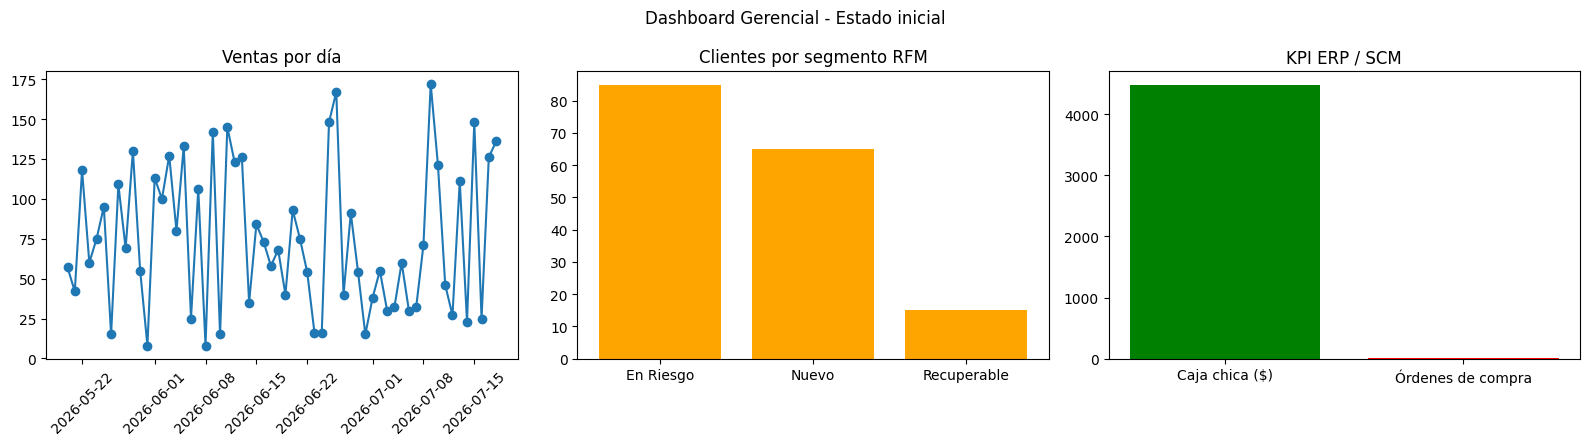

In [31]:
def graficar_dashboard(df_ventas, rfm, erp, scm, titulo="Dashboard Gerencial - FitZone"):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fig.suptitle(titulo)

    # 1. Ventas por día
    ventas_por_dia = df_ventas.groupby(df_ventas["fecha"].dt.date)["total"].sum()
    axes[0].plot(ventas_por_dia.index, ventas_por_dia.values, marker="o")
    axes[0].set_title("Ventas por día")
    axes[0].tick_params(axis="x", rotation=45)

    # 2. Clientes por segmento RFM
    conteo_segmentos = rfm["segmento"].value_counts()
    axes[1].bar(conteo_segmentos.index, conteo_segmentos.values, color="orange")
    axes[1].set_title("Clientes por segmento RFM")

    # 3. KPI financiero / inventario
    axes[2].bar(["Caja chica ($)", "Órdenes de compra"],
                [erp.caja_chica, len(scm.ordenes_compra)],
                color=["green", "red"])
    axes[2].set_title("KPI ERP / SCM")

    plt.tight_layout()
    plt.show()


graficar_dashboard(df_ventas, rfm, erp, scm, titulo="Dashboard Gerencial - Estado inicial")

## 11. Menú interactivo




===== FitZone - Menu principal =====
1. Registrar una venta
2. Ver alertas de clientes en riesgo (CRM)
3. Ver dashboard actualizado
4. Salir
Elige una opcion (1-4): 1

Hay 4000 clientes registrados (Cliente_1 a Cliente_4000).
Escribe el ID del cliente: 20

Productos disponibles:
1. Membresía Mensual (stock: 48)
2. Proteína en polvo (stock: 14)
3. Botella deportiva (stock: 25)
4. Clase personalizada (stock: 6)
5. Suplemento vitamínico (stock: 21)
Numero de producto: 2
Cantidad: 14
Venta registrada: Cliente_20 compró 14 x Proteína en polvo = $350.00
[ERP] Ingreso de $350.00 registrado. Caja chica actual: $4836.00
[SCM] Stock bajo de 'Proteína en polvo'. Se genera orden de compra automática al proveedor y se repone stock a 20 unidades.

===== FitZone - Menu principal =====
1. Registrar una venta
2. Ver alertas de clientes en riesgo (CRM)
3. Ver dashboard actualizado
4. Salir
Elige una opcion (1-4): 1

Hay 4000 clientes registrados (Cliente_1 a Cliente_4000).
Escribe el ID del cliente: 2


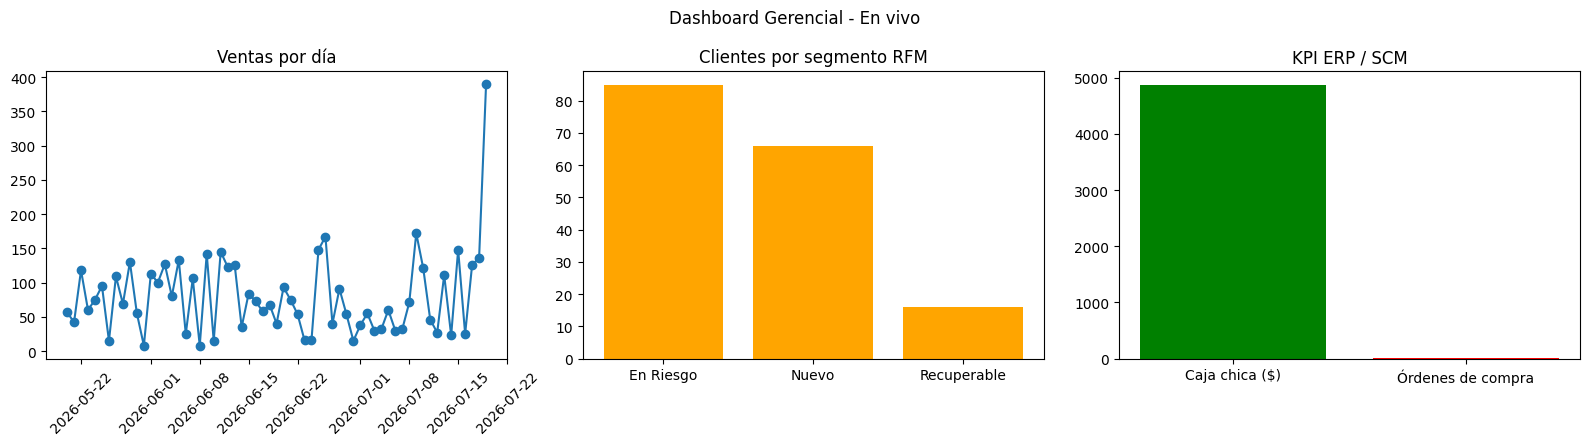


===== FitZone - Menu principal =====
1. Registrar una venta
2. Ver alertas de clientes en riesgo (CRM)
3. Ver dashboard actualizado
4. Salir


KeyboardInterrupt: Interrupted by user

In [32]:
def mostrar_menu():
    print("\n===== FitZone - Menu principal =====")
    print("1. Registrar una venta")
    print("2. Ver alertas de clientes en riesgo (CRM)")
    print("3. Ver dashboard actualizado")
    print("4. Salir")


def menu_interactivo():
    global df_ventas, rfm

    while True:
        mostrar_menu()
        opcion = input("Elige una opcion (1-4): ")

        if opcion == "1":
            print(f"\nHay {len(clientes)} clientes registrados (Cliente_1 a Cliente_{len(clientes)}).")
            id_cliente = int(input("Escribe el ID del cliente: "))

            print("\nProductos disponibles:")
            for i, p in enumerate(productos):
                print(f"{i + 1}. {p.nombre} (stock: {p.stock})")
            idx_producto = int(input("Numero de producto: ")) - 1

            cantidad = int(input("Cantidad: "))

            cliente_elegido = clientes[id_cliente - 1]
            producto_elegido = productos[idx_producto]
            gimnasio.registrar_venta(cliente_elegido, producto_elegido, cantidad, hoy)

            # Actualizamos historial, RFM y los archivos CSV con la nueva venta
            df_ventas, rfm = recalcular_historial()
            df_ventas.to_csv("historial_ventas.csv", index=False)
            rfm.to_csv("segmentacion_rfm.csv", index=False)

        elif opcion == "2":
            alertas_actuales = crm.revisar_clientes(gimnasio.clientes, hoy)
            print(f"\nSe encontraron {len(alertas_actuales)} clientes en riesgo. Mostrando las primeras 20:\n")
            for alerta in alertas_actuales[:20]:
                print("-", alerta)
            if len(alertas_actuales) > 20:
                print(f"... y {len(alertas_actuales) - 20} alertas más.")

        elif opcion == "3":
            df_ventas, rfm = recalcular_historial()
            graficar_dashboard(df_ventas, rfm, erp, scm, titulo="Dashboard Gerencial - En vivo")

        elif opcion == "4":
            print("\nSaliendo del sistema. Gracias por usar FitZone.")
            break

        else:
            print("\nOpcion invalida, intenta de nuevo.")


menu_interactivo()